In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [2]:
# 1. Path Dataset
train_dir = 'train'  # Folder untuk training
val_dir = 'val'      # Folder untuk validation
test_dir = 'test'    # Folder untuk testing

# 2. Hyperparameters
img_size = (224, 224)  # Ukuran gambar sesuai input MobileNetV3
batch_size = 32
epochs = 5
learning_rate = 0.0001

In [3]:
# 3. Data Preparation (Train, Validation, and Test)
datagen = ImageDataGenerator(rescale=1.0/255.0)

# Data Train
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Data Validation
val_data = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Data Test
test_data = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 69601 images belonging to 29 classes.
Found 8700 images belonging to 29 classes.
Found 8701 images belonging to 29 classes.


In [4]:
# 4. Model MobileNetV3
base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Membekukan layer pretrained
for layer in base_model.layers:
    layer.trainable = False

# Menambahkan Layer Klasifikasi
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

# Compile Model
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=learning_rate),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

4334752/4334752 [==============================] - 2s 1us/step


In [5]:
# Training Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    verbose=1
)

Epoch 1/5
2176/2176 [==============================] - 222s 95ms/step - loss: 3.3739 - accuracy: 0.0350 - val_loss: 3.3673 - val_accuracy: 0.0452
Epoch 2/5
2176/2176 [==============================] - 123s 57ms/step - loss: 3.3677 - accuracy: 0.0350 - val_loss: 3.3670 - val_accuracy: 0.0356
Epoch 3/5
2176/2176 [==============================] - 104s 48ms/step - loss: 3.3670 - accuracy: 0.0354 - val_loss: 3.3664 - val_accuracy: 0.0345
Epoch 4/5
2176/2176 [==============================] - 116s 53ms/step - loss: 3.3655 - accuracy: 0.0409 - val_loss: 3.3630 - val_accuracy: 0.0639
Epoch 5/5
2176/2176 [==============================] - 117s 54ms/step - loss: 3.3556 - accuracy: 0.0528 - val_loss: 3.3386 - val_accuracy: 0.0783


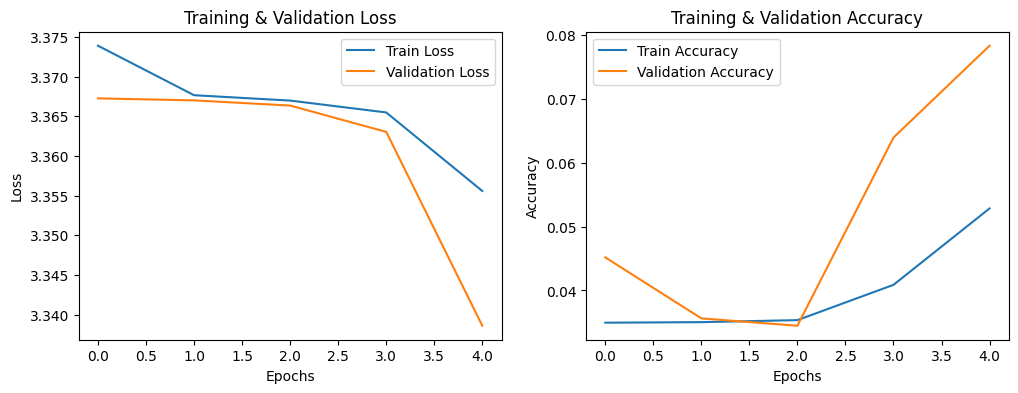

In [6]:
# 6. Evaluasi Model: Learning Curve
def plot_learning_curve(history):
    plt.figure(figsize=(12, 4))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

plot_learning_curve(history)

272/272 [==============================] - 22s 76ms/step


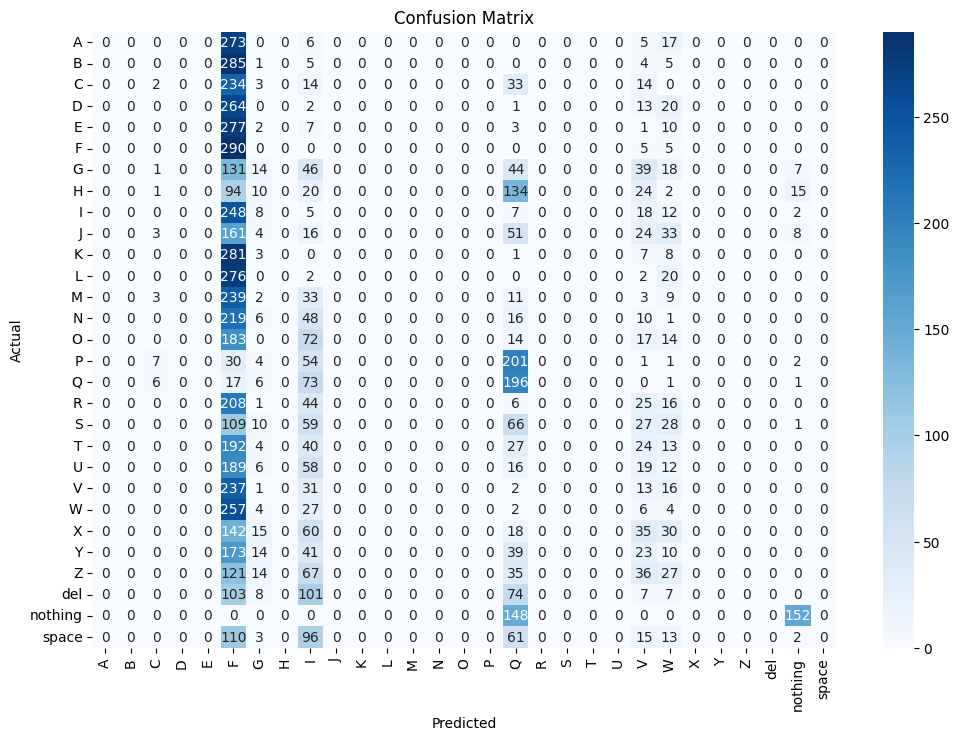

Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       301
           B       0.00      0.00      0.00       300
           C       0.09      0.01      0.01       300
           D       0.00      0.00      0.00       300
           E       0.00      0.00      0.00       300
           F       0.05      0.97      0.10       300
           G       0.10      0.05      0.06       300
           H       0.00      0.00      0.00       300
           I       0.00      0.02      0.01       300
           J       0.00      0.00      0.00       300
           K       0.00      0.00      0.00       300
           L       0.00      0.00      0.00       300
           M       0.00      0.00      0.00       300
           N       0.00      0.00      0.00       300
           O       0.00      0.00      0.00       300
           P       0.00      0.00      0.00       300
           Q       0.16      0.65      0.26       300
    

C:\Users\ercom\anaconda3\envs\prakNN_tf2_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ercom\anaconda3\envs\prakNN_tf2_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ercom\anaconda3\envs\prakNN_tf2_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [7]:
# 7. Confusion Matrix & Classification Report
# Evaluasi pada Test Data
y_true = test_data.classes
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_data.class_indices.keys(), yticklabels=test_data.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=test_data.class_indices.keys()))
